In [1]:
import sys
from pathlib import Path

root = Path(r"C:\Users\66802\REPO\smol-llm")     
sys.path.insert(0, str(root / "src"))            

import torch

ckpt = torch.load(root / "checkpoints/mini/step_15000.pt", map_location="cpu", weights_only=False)
hist = ckpt["history"]

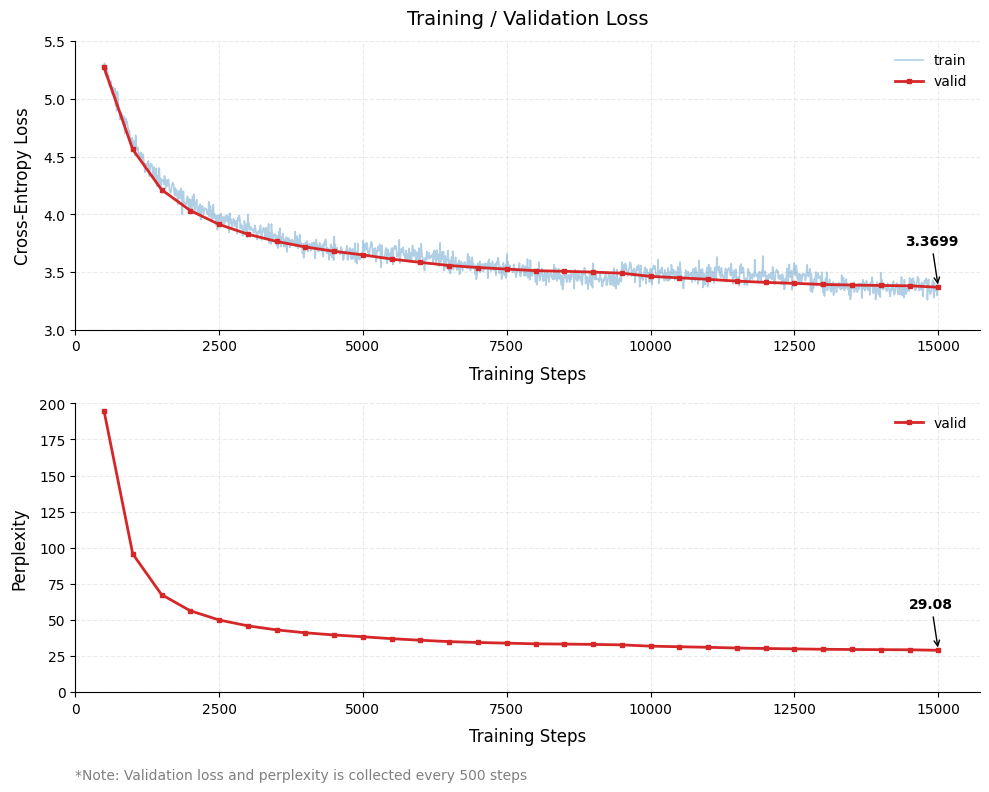

In [39]:
import matplotlib.pyplot as plt

step_interval = 500
val_step = [i * step_interval for i in range(1, len(hist["val_loss"]))]

fig, ax = plt.subplots(2, 1, figsize=(10, 8))

train_loss = hist["train_loss"][::10]  # takes every 10 points to make the plot smoother
train_step = hist["step"][::10] 
# Validation plot ignore the first value because it is saved before step 500
# Training/Validation loss
ax[0].plot(
    train_step[50:],
    train_loss[50:],
    color="tab:blue",
    alpha=0.35,
    linewidth=1.2,
    label="train"
)

ax[0].plot(
    val_step,
    hist["val_loss"][1:],
    color="tab:red",
    linewidth=2,
    marker='s',
    markersize=2.5,
    label="valid"
)

ax[0].grid(True, which="both", alpha=0.25, linestyle="--")
ax[0].set_xticks(range(0, 15100, 2500))
ax[0].set_xlim(left=0)
ax[0].set_ylim(3, 5.5)

# Remove unnecessary borders
ax[0].spines["top"].set_visible(False)
ax[0].spines["right"].set_visible(False)

last_x, last_y = hist["step"][-1], hist["val_loss"][-1]

ax[0].annotate(
    f"{last_y:.4f}",
    xy=(last_x, last_y),
    xytext=(-5, 28),
    textcoords="offset points",
    ha="center",
    va="bottom",
    fontsize=10,
    fontweight="bold",
    arrowprops=dict(
        arrowstyle="->",
        color="black",
        lw=1
    )
)

ax[0].set_xlabel("Training Steps", fontsize=12, labelpad=8)
ax[0].set_ylabel("Cross-Entropy Loss", fontsize=12, labelpad=8)
ax[0].set_title("Training / Validation Loss", fontsize=14, pad=12)
ax[0].legend(frameon=False)


# Perplexity plot
ax[1].plot(
    val_step,
    hist["val_ppl"][1:],
    color="tab:red",
    linewidth=2,
    marker='s',
    markersize=2.5,
    label="valid"
)

ax[1].text(
    0.0,
    -0.3,
    "*Note: Validation loss and perplexity is collected every 500 steps",
    transform=plt.gca().transAxes,
    fontsize=10, 
    color="gray"
)

ax[1].grid(True, which="both", alpha=0.25, linestyle="--")
ax[1].set_xticks(range(0, 15100, 2500))
ax[1].set_xlim(left=0)
ax[1].set_ylim(0, 200)

# Remove unnecessary borders
ax[1].spines["top"].set_visible(False)
ax[1].spines["right"].set_visible(False)

last_ppl = hist["val_ppl"][-1]

ax[1].annotate(
    f"{last_ppl:.2f}",
    xy=(last_x, last_ppl),
    xytext=(-5, 28),
    textcoords="offset points",
    ha="center",
    va="bottom",
    fontsize=10,
    fontweight="bold",
    arrowprops=dict(
        arrowstyle="->",
        color="black",
        lw=1
    )
)

ax[1].set_xlabel("Training Steps", fontsize=12, labelpad=8)
ax[1].set_ylabel("Perplexity", fontsize=12, labelpad=8)
ax[1].legend(frameon=False)

plt.tight_layout()
plt.show()
